In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv("../../Datasets/playground-s5-e8/train.csv")
test = pd.read_csv("../../Datasets/playground-s5-e8/test.csv")

In [45]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [46]:
df.describe()

,id,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,216506.495284,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,0.000000,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,187499.750000,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,374999.500000,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,562499.250000,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,749999.000000,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [47]:
df.shape

(750000, 18)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB


In [49]:
object_columns = df.select_dtypes(include=['object']).columns

In [50]:
for i in object_columns:
    print(df[i].value_counts())

job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64
marital
married     480759
single      194834
divorced     74407
Name: count, dtype: int64
education
secondary    401683
tertiary     227508
primary       99510
unknown       21299
Name: count, dtype: int64
default
no     737151
yes     12849
Name: count, dtype: int64
housing
yes    411288
no     338712
Name: count, dtype: int64
loan
no     645023
yes    104977
Name: count, dtype: int64
contact
cellular     486655
unknown      231627
telephone     31718
Name: count, dtype: int64
month
may    228411
aug    128859
jul    110647
jun     93670
nov     66062
apr     41319
feb     37611
jan     18937
oct      9204
sep      7409
mar      5802
dec      2069
Name: count, dtype: int6

In [51]:
df.isnull().sum()

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [56]:
from sklearn.preprocessing import LabelEncoder
le_dict = {}
df_encoded = df.copy()
test_encoded = test.copy()

for col in object_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    test_values = test[col].astype(str)
    test_encoded[col] = le.transform(test_values)
    le_dict[col] = le

In [53]:
df_encoded.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,9,1,1,0,7,0,0,0,25,1,117,3,-1,0,3,0
1,1,38,1,1,1,0,514,0,0,2,18,6,185,1,-1,0,3,0
2,2,36,1,1,1,0,602,1,0,2,14,8,111,2,-1,0,3,0
3,3,27,8,2,1,0,34,1,0,2,28,8,10,2,-1,0,3,0
4,4,26,9,1,1,0,889,1,0,0,3,3,902,1,-1,0,3,1


<Axes: >

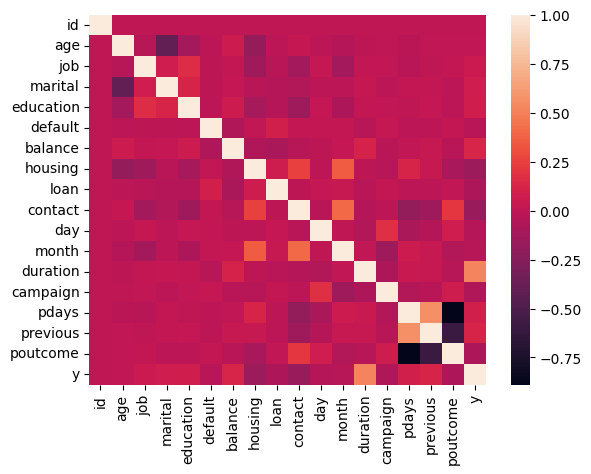

In [67]:
sns.heatmap(df_encoded.corr())

In [77]:
df_encoded.corr()['y']

id           0.000615
age          0.009523
job          0.054058
marital      0.073598
education    0.080259
default     -0.030134
balance      0.122513
housing     -0.153589
loan        -0.081639
contact     -0.158278
day         -0.049625
month       -0.035114
duration     0.519283
campaign    -0.075829
pdays        0.089277
previous     0.119552
poutcome    -0.077042
y            1.000000
Name: y, dtype: float64

In [ ]:
# drop_cols = ['age','job','default','day','month']
# df_encoded.drop(columns=drop_cols,inplace=True)
# test_encoded.drop(columns=drop_cols,inplace=True)

In [79]:
X = df_encoded.drop(['y', 'id'], axis=1)
y = df_encoded['y']
X_test = test_encoded.drop(['id'], axis=1)

In [ ]:
# from xgboost import XGBClassifier

# # model = XGBClassifier(random_state=9)

# # model.fit(X,y)

# import optuna
# from sklearn.model_selection import cross_val_score

# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 3, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
#         'gamma': trial.suggest_float('gamma', 0, 0.5),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
#         'random_state': 42
#     }
    
#     model = XGBClassifier(**params)
    
#     scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
#     return scores.mean()

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=100)

# print("Best parameters:", study.best_params)
# print("Best score:", study.best_value)

# best_model = XGBClassifier(**study.best_params)
# best_model.fit(X, y)

In [88]:
params = {'n_estimators': 498, 'max_depth': 6, 'learning_rate': 0.2555079485093256, 'subsample': 0.9330747545901773, 'colsample_bytree': 0.6938007386666315, 'gamma': 0.0037379723635113105, 'reg_alpha': 0.8664521336681718, 'reg_lambda': 0.8162964542328879}

In [90]:
from xgboost import XGBClassifier

model = XGBClassifier(**params)

model.fit(X,y)
y_pred = model.predict_proba(X_test)[:,1]
y_pred

array([1.6053857e-03, 7.6886602e-02, 1.0209150e-04, ..., 3.2711431e-01,
       6.2558131e-04, 3.2813992e-02], dtype=float32)

In [91]:
submission = pd.DataFrame({
    'id': test['id'],
    'y': y_pred
})
submission.to_csv('predictions.csv', index=False)